In [1]:
# DL dataset
'''
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)
'''

'\nimport kagglehub\n\n# Download latest version\npath = kagglehub.dataset_download("grassknoted/asl-alphabet")\n\nprint("Path to dataset files:", path)\n'

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [3]:
test_dir = "dataset/asl_alphabet_train/asl_alphabet_test"
train_dir  = "dataset/asl_alphabet_train/asl_alphabet_train"

for dirpath, dirnames, filenames in os.walk(r"dataset"):
    if len(filenames) > 0:
        print(f"There are {len(filenames)} images in '{dirpath}'.")

There are 28 images in 'dataset\asl_alphabet_test\asl_alphabet_test'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\A'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\B'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\C'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\D'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\del'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\E'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\F'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\G'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\H'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\I'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\J'.
There are 3000 images in 'dataset\asl_alphabet_train\asl_alphabet_train\K'.
There are 3000 i

In [4]:
TRAIN_DIR = r'dataset\asl_alphabet_train\asl_alphabet_train'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 16

train_data = tf.keras.utils.image_dataset_from_directory(
    directory=TRAIN_DIR,
    image_size=IMG_SIZE,
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    subset="training",
    shuffle=True,
    seed=42
)

val_data = tf.keras.utils.image_dataset_from_directory(
    directory=TRAIN_DIR,
    image_size=IMG_SIZE,
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="validation",
    shuffle=False,
    seed=42
)

Found 87000 files belonging to 29 classes.
Using 73950 files for training.
Found 87000 files belonging to 29 classes.
Using 17400 files for validation.


In [5]:
# Check the class names
class_names = train_data.class_names
print(f"Class names: {class_names}")
print(f"Number of classes: {len(class_names)}")

Class names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Number of classes: 29


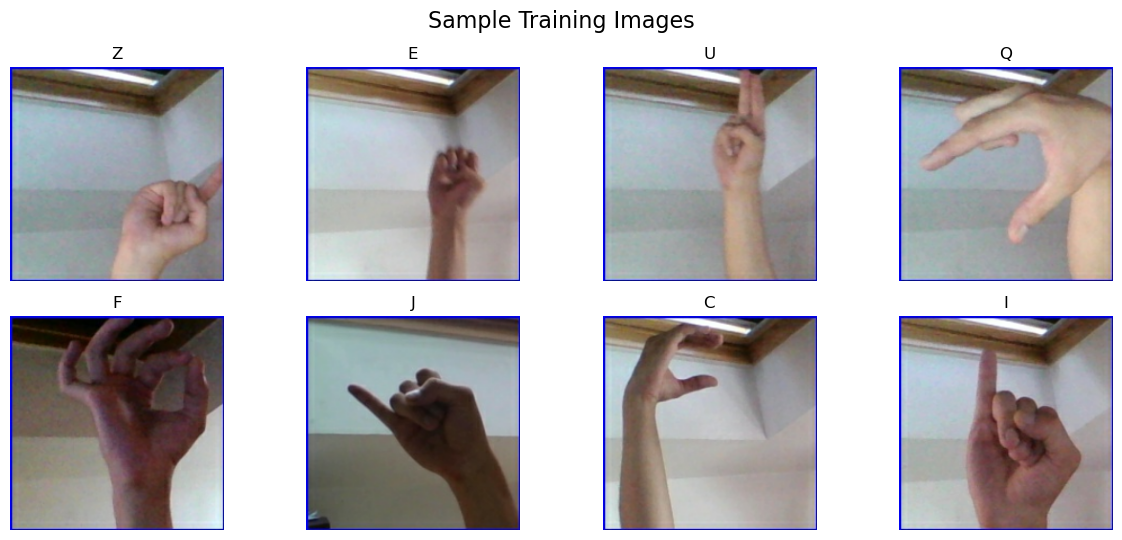

In [6]:
plt.figure(figsize=(12, 8))
for images, labels in train_data.take(1):
    for i in range(8):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[tf.argmax(labels[i]).numpy()])
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),      
    layers.RandomRotation(0.2),          
    layers.RandomZoom(0.2),                
    layers.RandomHeight(0.2),              
    layers.RandomWidth(0.2),                
], name="data_augmentation")

print("Data augmentation layer created!")

Data augmentation layer created!


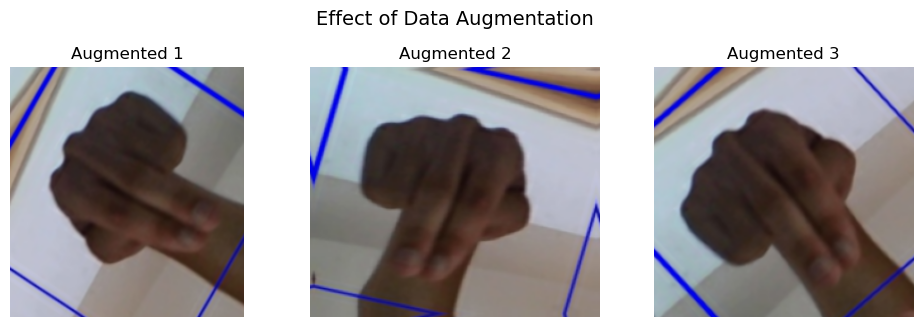

In [8]:
plt.figure(figsize=(10, 6))
for images, _ in train_data.take(1):
    sample_image = images[0]
    for i in range(3):
        augmented = data_augmentation(tf.expand_dims(sample_image, axis=0))
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(tf.squeeze(augmented).numpy().astype("uint8"))
        plt.title(f"Augmented {i+1}")
        plt.axis("off")
plt.suptitle("Effect of Data Augmentation", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics.
    """
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(loss))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [10]:
def compare_historys(original_history, new_history, initial_epochs=5):
    """
    Compares two model history objects (before and after fine-tuning).
    """
    acc     = original_history.history["accuracy"]
    loss    = original_history.history["loss"]
    val_acc  = original_history.history["val_accuracy"]
    val_loss = original_history.history["val_loss"]

    total_acc     = acc     + new_history.history["accuracy"]
    total_loss    = loss    + new_history.history["loss"]
    total_val_acc  = val_acc  + new_history.history["val_accuracy"]
    total_val_loss = val_loss + new_history.history["val_loss"]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(total_acc, label="training_accuracy")
    plt.plot(total_val_acc, label="val_accuracy")
    plt.axvline(x=initial_epochs - 1, color="red", linestyle="--", label="Start Fine-Tuning")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(total_loss, label="training_loss")
    plt.plot(total_val_loss, label="val_loss")
    plt.axvline(x=initial_epochs - 1, color="red", linestyle="--", label="Start Fine-Tuning")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [11]:
import datetime

def create_tensorboard_callback(dir_name, experiment_name):
    """
    Creates a TensorBoard callback to log model training metrics.
    """
    log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
    print(f"Saving TensorBoard log files to: {log_dir}")
    return tensorboard_callback

In [12]:
checkpoint_path = "model_checkpoints/checkpoint.weights.h5"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,  
    save_best_only=True,     
    save_freq="epoch",       
    verbose=1
)

print(f"Model weights will be saved to: {checkpoint_path}")

Model weights will be saved to: model_checkpoints/checkpoint.weights.h5


In [13]:
import tensorflow as tf
from tensorflow.keras import layers

# 1. Clear session again just to be safe
tf.keras.backend.clear_session()

# 2. Build the model architecture WITHOUT weights first.
# This avoids the immediate crash during initialization.
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights=None, 
    input_shape=(224, 224, 3)
)

# 3. Now, try to load the weights separately. 
# If this fails, your downloaded weight file is definitely corrupted.
try:
    # This downloads/links the official ImageNet weights
    weights_path = tf.keras.utils.get_file(
        "efficientnetb0_notop.h5",
        "https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5",
        cache_subdir="models"
    )
    base_model.load_weights(weights_path)
    print("Weights loaded successfully!")
except Exception as e:
    print(f"Manual weight loading failed: {e}")

# 4. Proceed with your functional model
base_model.trainable = False
inputs = layers.Input(shape=(224, 224, 3), name="input_layer")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
outputs = layers.Dense(len(class_names), activation="softmax", name="output_layer")(x)

model = tf.keras.Model(inputs, outputs)


Weights loaded successfully!


In [14]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 29)             │        37,149 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,086,720 (15.59 MB)

 Trainable params: 37,149 (145.11 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
initial_epochs = 5

history_feature_extraction = model.fit(
    train_data,
    epochs=initial_epochs,
    validation_data=val_data,
    validation_steps=int(0.25 * len(val_data)), 
    callbacks=[
        create_tensorboard_callback("transfer_learning", "feature_extraction"),
        checkpoint_callback
    ]
)

Saving TensorBoard log files to: transfer_learning/feature_extraction/20260323-103327
Epoch 1/5
3503/4622 ━━━━━━━━━━━━━━━━━━━━ 13:40 733ms/step - accuracy: 0.6083 - loss: 1.5634

KeyboardInterrupt: 